In [ ]:
!pip install opencv-python-headless scikit-image scikit-learn matplotlib joblib tqdm

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import joblib

In [ ]:
def extract_hog(img):
    hog_features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return hog_features


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/train"

In [ ]:
IMAGE_SIZE = (100, 100)

all_files = os.listdir(TRAIN_DIR)
cats = sorted([f for f in all_files if f.startswith("cat")])[:1000]
dogs = sorted([f for f in all_files if f.startswith("dog")])[:1000]

selected_images = cats + dogs
print("Total selected images:", len(selected_images))

features = []
labels = []

for img_name in tqdm(selected_images):
    img_path = os.path.join(TRAIN_DIR, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, IMAGE_SIZE)
    hog_feat = extract_hog(img)
    features.append(hog_feat)
    labels.append(0 if img_name.startswith("cat") else 1)

X = np.array(features)
y = np.array(labels)
print("X shape:", X.shape)
print("y shape:", y.shape)

Total selected images: 2000


100%|██████████| 2000/2000 [01:01<00:00, 32.74it/s]

X shape: (2000, 4356)
y shape: (2000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 1600
Test samples: 400


In [ ]:
svm = SVC(kernel='rbf', gamma='scale')

print("Training SVM (this may take a while)...")
svm.fit(X_train, y_train)
print("Training completed!")

Training SVM (this may take a while)...
Training completed!


Accuracy: 0.685

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.75      0.70       200
           1       0.71      0.62      0.66       200

    accuracy                           0.69       400
   macro avg       0.69      0.69      0.68       400
weighted avg       0.69      0.69      0.68       400



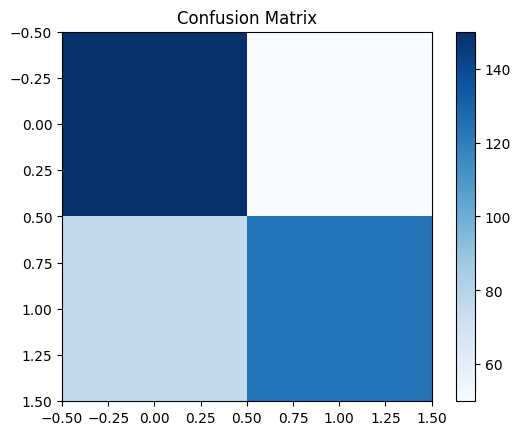

In [ ]:
y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
joblib.dump(svm, "svm_cats_dogs_model.pkl")
print("Model saved as svm_cats_dogs_model.pkl")

Model saved as svm_cats_dogs_model.pkl


In [ ]:
from google.colab import files
uploaded = files.upload()
test_img_path = list(uploaded.keys())[0]
print("Selected:", test_img_path)

Saving cat.1.jpg to cat.1.jpg
Selected: cat.1.jpg


In [ ]:
def preprocess_single_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMAGE_SIZE)

    hog_feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return hog_feat, img

Saving cat.1.jpg to cat.1 (2).jpg

Testing: cat.1 (2).jpg


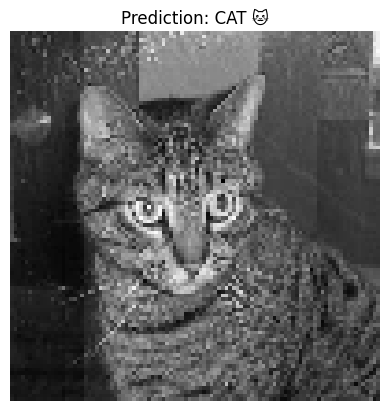

Result: CAT 🐱

Upload more? (If no, just close the upload window)


Saving dog.1.jpg to dog.1.jpg

Testing: dog.1.jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


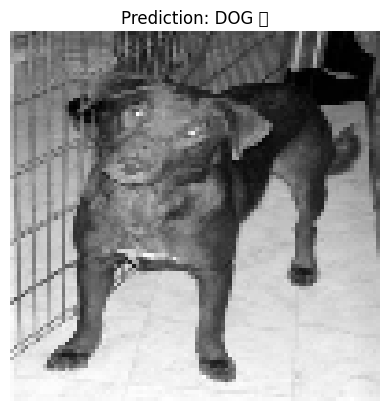

Result: DOG 🐶

Upload more? (If no, just close the upload window)


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

while True:
    uploaded = files.upload()
    if not uploaded:
        break

    for img_name in uploaded.keys():
        print("\n==============================")
        print("Testing:", img_name)
        print("==============================")

        hog_feat, img = preprocess_single_image(img_name)
        prediction = svm.predict([hog_feat])[0]

        label = "CAT 🐱" if prediction == 0 else "DOG 🐶"

        plt.imshow(img, cmap='gray')
        plt.title(f"Prediction: {label}")
        plt.axis('off')
        plt.show()

        print("Result:", label)

    print("\nUpload more? (If no, just close the upload window)")
